# Monte Carlo Integration and Variance Reduction

<a target="_blank" href="https://colab.research.google.com/github/JunyoungB/statistical-computing-public/blob/main/ch4.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Monte Carlo Integration

 ### Simple Monte Carlo Integration

In [ ]:
import numpy as np

m = 10000
#seed = 2026
#rng = np.random.default_rng(seed)

x = np.random.random(m)                  # Uniform(0,1)
theta_hat = np.mean(np.exp(-x))    # g(x)=exp(-x)

print(theta_hat)
print(1 - np.exp(-1))

### Simple Monte Carlo Integration on (2,4)

In [4]:
x = np.random.uniform(2.0, 4.0, size=m)        # Uniform(2,4)
theta_hat = np.mean(np.exp(-x)) * 2.0    # (b-a)=2

print(theta_hat)
print(np.exp(-2) - np.exp(-4))

0.1169527626124318
0.11701964434787852


### Monte Carlo Estimate of $\Phi(x)$

In [7]:
from scipy.stats import norm

m=1000
x = np.linspace(0.1, 2.5, 10)
u = np.random.random(m)  # Uniform(0,1)
cdf = np.empty_like(x)

for i, xi in enumerate(x):
    g = xi * np.exp(-(u * xi) ** 2 / 2.0)
    cdf[i] = np.mean(g) / np.sqrt(2 * np.pi) + 0.5

Phi = norm.cdf(x)
print(np.round(np.vstack([x, cdf, Phi]), 3))

[[0.1   0.367 0.633 0.9   1.167 1.433 1.7   1.967 2.233 2.5  ]
 [0.54  0.643 0.737 0.816 0.878 0.925 0.956 0.977 0.99  0.997]
 [0.54  0.643 0.737 0.816 0.878 0.924 0.955 0.975 0.987 0.994]]


### Indicator Estimator of $\Phi(x)$

In [10]:
z = np.random.standard_normal(m)
p = (z[:, None] < x).mean(axis=0)

Phi = norm.cdf(x)
print(np.round(np.vstack([x, p, Phi]), 3))

[[0.1   0.367 0.633 0.9   1.167 1.433 1.7   1.967 2.233 2.5  ]
 [0.536 0.638 0.732 0.808 0.88  0.923 0.952 0.974 0.986 0.993]
 [0.54  0.643 0.737 0.816 0.878 0.924 0.955 0.975 0.987 0.994]]


### Variance Estimate and Confidence Interval

In [12]:
m = 10000
z = np.random.standard_normal(m)

for x in [2.0, 2.5]:
    g = (z < x).astype(float)                 # indicator
    cdf = np.mean(g)
    v = np.mean((g - cdf) ** 2) / m           # variance estimate
    print(cdf, v)
    print(cdf - 1.96 * np.sqrt(v), cdf + 1.96 * np.sqrt(v))

0.976 2.3424000000000002e-06
0.9730002393695496 0.9789997606304504
0.9936 6.35904e-07
0.9920370256539534 0.9951629743460467


## Antithetic Variables

In [13]:
def mc_phi(x, R=10000, antithetic=True):
    u = np.random.random(R // 2)
    v = (1.0 - u) if antithetic else np.random.random(R // 2)
    u = np.concatenate([u, v])

    x = np.atleast_1d(x).astype(float)
    cdf = np.empty_like(x)

    for i, xi in enumerate(x):
        g = xi * np.exp(- (u * xi) ** 2 / 2.0)
        cdf[i] = np.mean(g) / np.sqrt(2.0 * np.pi) + 0.5
    return cdf

In [14]:
x = np.linspace(0.1, 2.5, 5)
Phi = norm.cdf(x)

MC1 = mc_phi(x, R=10000, antithetic=False)
MC2 = mc_phi(x, R=10000, antithetic=True)

print(np.round(np.vstack([x, MC1, MC2, Phi]), 5))

[[0.1     0.7     1.3     1.9     2.5    ]
 [0.53983 0.758   0.90292 0.9704  0.99209]
 [0.53983 0.75807 0.90331 0.97137 0.99363]
 [0.53983 0.75804 0.9032  0.97128 0.99379]]


### Reduction in Variance

In [15]:
m=1000

MC1 = np.zeros(m)
MC2 = np.zeros(m)

for i in range(m):
    MC1[i] = mc_phi(1.95, R=1000, antithetic=False)[0]
    MC2[i] = mc_phi(1.95, R=1000, antithetic=True)[0]

print(np.std(MC1))
print(np.std(MC2))
print((np.var(MC1) - np.var(MC2)) / np.var(MC1))

0.006687525927752381
0.000451177043794362
0.9954484110852166


## Control Variates

In [16]:
m = 10000

a = -12.0 + 6.0 * (np.e - 1.0)

U = np.random.random(m)
T1 = np.exp(U)                  # simple MC
T2 = np.exp(U) + a * (U - 0.5)  # controlled

print(np.mean(T1))
print(np.mean(T2))
print((np.var(T1, ddof=1) - np.var(T2, ddof=1)) / np.var(T1, ddof=1))

1.7143256003662277
1.7193389067318334
0.9837116485964698


## Importance Sampling

In [17]:
m = 10000

theta_hat = np.zeros(5)
sd_hat = np.zeros(5)

def g(x):
    return np.exp(-x) / (1.0 + x ** 2) * (x > 0.0) * (x < 1.0)

# f0: Uniform(0,1)
x = np.random.random(m)
fg = g(x)                         # divide by f0(x)=1 on (0,1)
theta_hat[0], sd_hat[0] = fg.mean(), fg.std(ddof=1)

# f1: Exp(rate=1), support (0, inf)
x = np.random.exponential(scale=1.0, size=m)
fg = g(x) / np.exp(-x)   # divide by f1(x)=exp(-x)
theta_hat[1], sd_hat[1] = fg.mean(), fg.std(ddof=1)

# f2: Standard Cauchy, support R
x = np.random.standard_cauchy(m)
x[(x < 0) | (x >1)] = 2.   #to catch overflow errors in g(x)
fg = g(x) / (1.0 / (np.pi * (1.0 + x**2)))     
theta_hat[2], sd_hat[2] = fg.mean(), fg.std(ddof=1)

# f3: truncated exp on (0,1) via inverse transform
u = np.random.random(m)
x = -np.log(1.0 - u * (1.0 - np.exp(-1.0)))
fg = g(x) / (np.exp(-x) / (1.0 - np.exp(-1.0)))
theta_hat[3], sd_hat[3] = fg.mean(), fg.std(ddof=1)

# f4: density 4/(pi(1+x^2)) on (0,1) via inverse transform
u = np.random.random(m)
x = np.tan(np.pi * u / 4.0)
fg = g(x) / (4.0 / (np.pi * (1.0 + x**2)))
theta_hat[4], sd_hat[4] = fg.mean(), fg.std(ddof=1)

In [18]:
print(np.vstack([theta_hat, sd_hat / np.sqrt(m)]))

[[0.52375883 0.52427606 0.52982214 0.52529983 0.52475835]
 [0.00245593 0.00419374 0.00953299 0.00096547 0.00141735]]


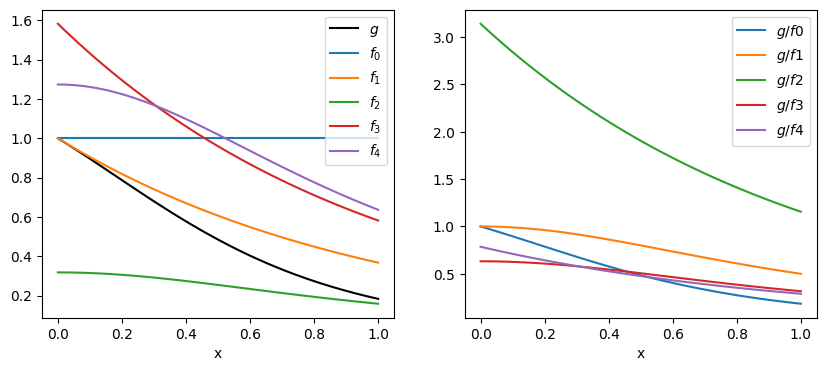

In [20]:
import matplotlib.pyplot as plt

x = np.linspace(0, 1, 100)

g = np.exp(-x) / (1.0 + x**2)
f0 = np.ones_like(x)
f1 = np.exp(-x)
f2 = 1.0 / (np.pi * (1.0 + x**2))
f3 = np.exp(-x) / (1.0 - np.exp(-1.0))
f4 = 4.0 / (np.pi * (1.0 + x**2))

fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(x, g,  label="$g$", color='k')
for i, f in enumerate([f0, f1, f2, f3, f4]):
    ax[0].plot(x, f, label="$f_%d$"%i)
    ax[1].plot(x, g/f, label="$g/f%d$"%i)

ax[0].legend(); ax[1].legend()
ax[0].set_xlabel("x"); ax[1].set_xlabel("x")
#plt.savefig("figs/4-1.png", dpi=160, bbox_inches="tight")
plt.show()

## Stratified Sampling

In [24]:
M = 20  # total replicates
estimates = np.zeros((10, 2))

def g(x):
    return np.exp(-x) / (1.0 + x ** 2) * (x > 0.0) * (x < 1.0)

for i in range(10):
    estimates[i, 0] = np.mean(g(np.random.random(M)))

    # 4 equal strata, M/4 replicates per stratum
    T2 = np.empty(4)
    T2[0] = np.mean(g(np.random.uniform(0.00, 0.25, size=M//4)))
    T2[1] = np.mean(g(np.random.uniform(0.25, 0.50, size=M//4)))
    T2[2] = np.mean(g(np.random.uniform(0.50, 0.75, size=M//4)))
    T2[3] = np.mean(g(np.random.uniform(0.75, 1.00, size=M//4)))
    estimates[i, 1] = np.mean(T2)

print(estimates.mean(axis=0))
print(estimates.var(axis=0, ddof=1))

[0.51474312 0.53274468]
[0.00216152 0.00035346]
